In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')

In [9]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\HP\Downloads\Superstore.csv",
    encoding="latin1"
)

In [10]:
print(df.columns.tolist())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales']


In [11]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert dates
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    format='%d-%m-%Y',
    errors='coerce'
)

df['Ship_Date'] = pd.to_datetime(
    df['Ship_Date'],
    format='%d-%m-%Y',
    errors='coerce'
)
# Convert Sales to numeric
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

print(df.head())

   Row_ID        Order_ID Order_Date  Ship_Date       Ship_Mode Customer_ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer_Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   
4    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   

   Postal_Code Region       Product_ID         Category Sub_Ca

In [12]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month_name()

In [13]:
total_revenue = df['Sales'].sum()

average_order_value = df.groupby('Order_ID')['Sales'].sum().mean()

print("Total Revenue:", round(total_revenue,2))
print("Average Order Value:", round(average_order_value,2))
print("Profit Margin: Not Available in this dataset")
print("Conversion Metric: Not Available in this dataset")

Total Revenue: 2261536.78
Average Order Value: 459.48
Profit Margin: Not Available in this dataset
Conversion Metric: Not Available in this dataset


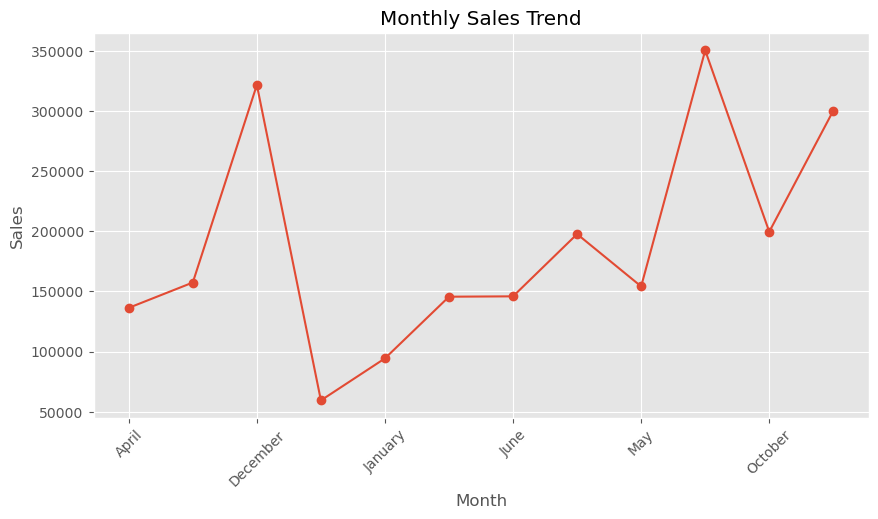

In [14]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

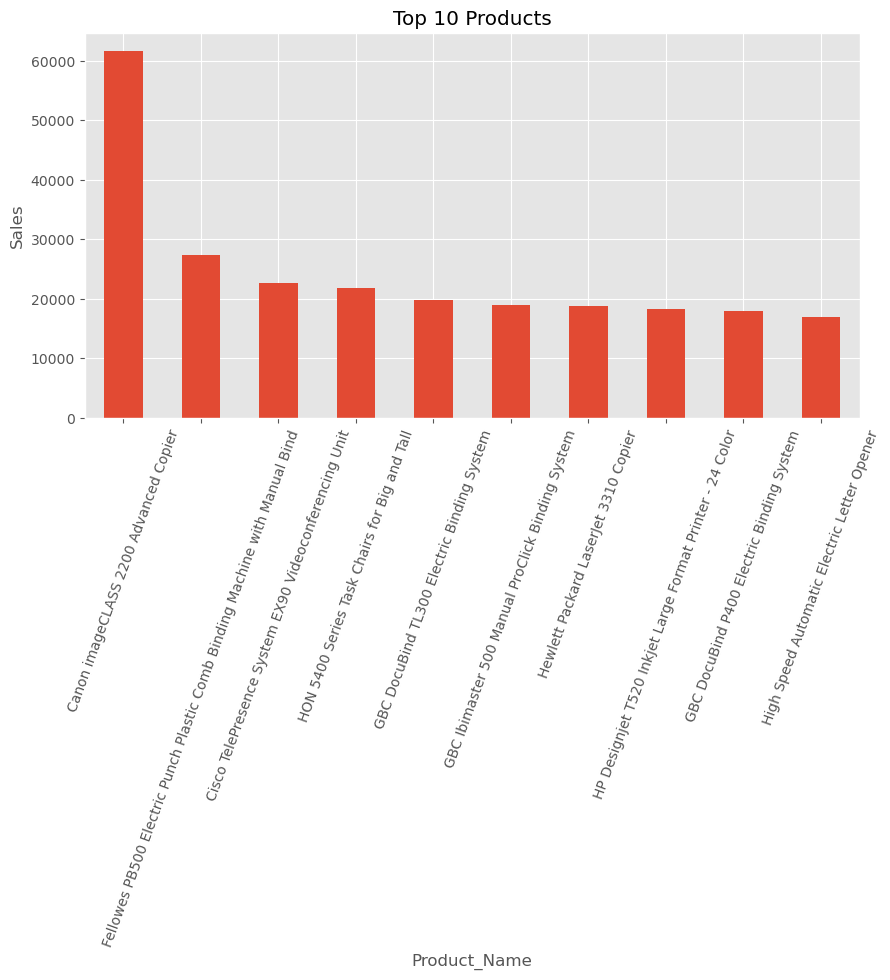

In [15]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_products.plot(kind='bar')

plt.title("Top 10 Products")

plt.ylabel("Sales")

plt.xticks(rotation=70)

plt.show()

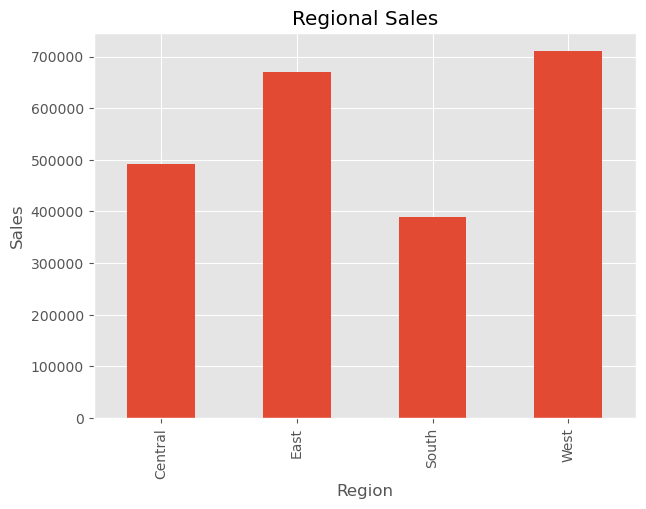

In [16]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(7,5))

region_sales.plot(kind='bar')

plt.title("Regional Sales")

plt.ylabel("Sales")

plt.show()

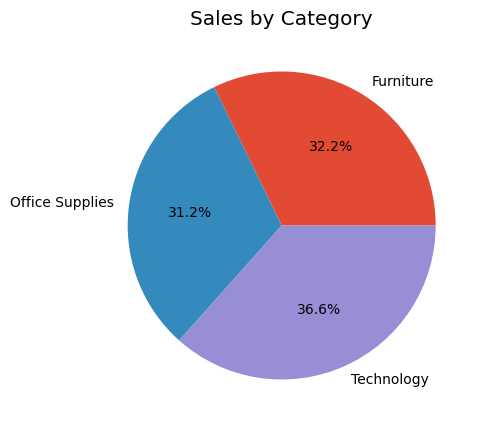

In [17]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(7,5))

category_sales.plot(kind='pie', autopct='%1.1f%%')

plt.ylabel("")

plt.title("Sales by Category")

plt.show()

In [18]:
print("Top 5 Products")

print(df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head())

print("\nWorst 5 Products")

print(df.groupby('Product_Name')['Sales'].sum().sort_values().head())

Top 5 Products
Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

Worst 5 Products
Product_Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Name: Sales, dtype: float64


In [19]:
seasonality = df.groupby('Month')['Sales'].sum()

print(seasonality.sort_values(ascending=False))

Month
November     350161.7110
December     321480.1695
September    300103.4117
October      199496.2947
March        197573.5872
August       157315.9270
May          154086.7237
June         145837.5233
July         145535.6890
April        136283.0006
January       94291.6296
February      59371.1154
Name: Sales, dtype: float64
